# Titanic Hayatta Kalma Tahmini

Bu not defteri, `src/` modüllerini kullanarak Titanic veri seti üzerinde uçtan uca bir makine öğrenmesi pipeline'ı yürütür.
Her adım için kısa bir açıklama ve ilgili `src/` fonksiyon çağrısı yer almaktadır.

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Adım 1 — Veri Yükleme

Ham CSV dosyasını okur; satır/sütun sayısını ve eksik değerleri raporlar.
Veri setinde 891 yolcu kaydı ve 12 sütun bulunmaktadır.
Hedef değişken `Survived`: 0 = hayatta kalmadı, 1 = hayatta kaldı (~%38 pozitif).

In [2]:
from src.data_loader import load_data

df = load_data()
df.head()

Şekil: (891, 12)
Sütunlar: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Eksik değerler:
Age         177
Cabin       687
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Adım 2 — Keşifsel Veri Analizi (EDA)

Ham veri üzerinde üç grafik oluşturulur ve `results/figures/` klasörüne kaydedilir:
- **fig1**: Hayatta kalma dağılımı
- **fig2**: Cinsiyete ve yolcu sınıfına göre hayatta kalma oranı
- **fig3**: Yaşa göre hayatta kalma dağılımı (yığılmış histogram)

EDA; sütun yeniden adlandırmasından **önce** çalıştırılır.

EDA grafikleri kaydedildi.


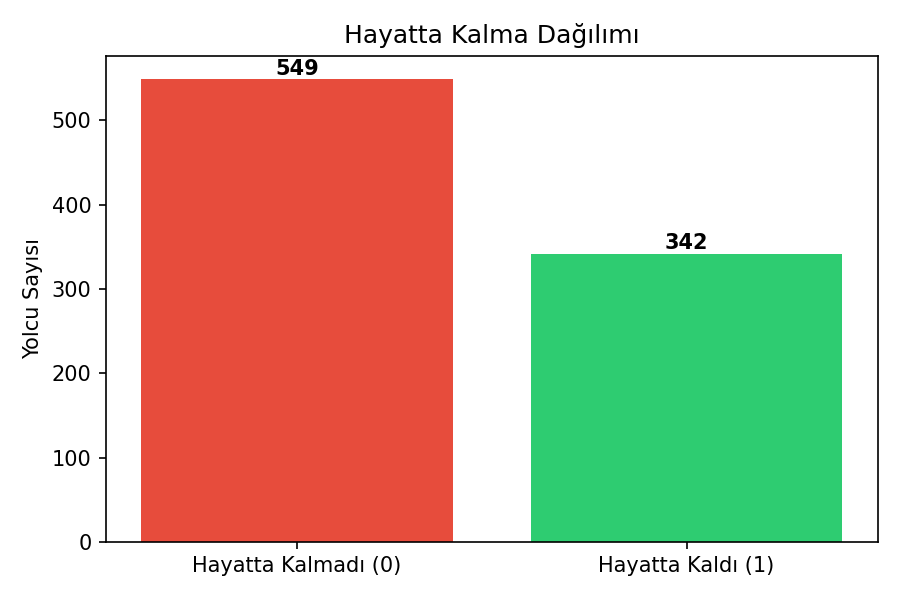

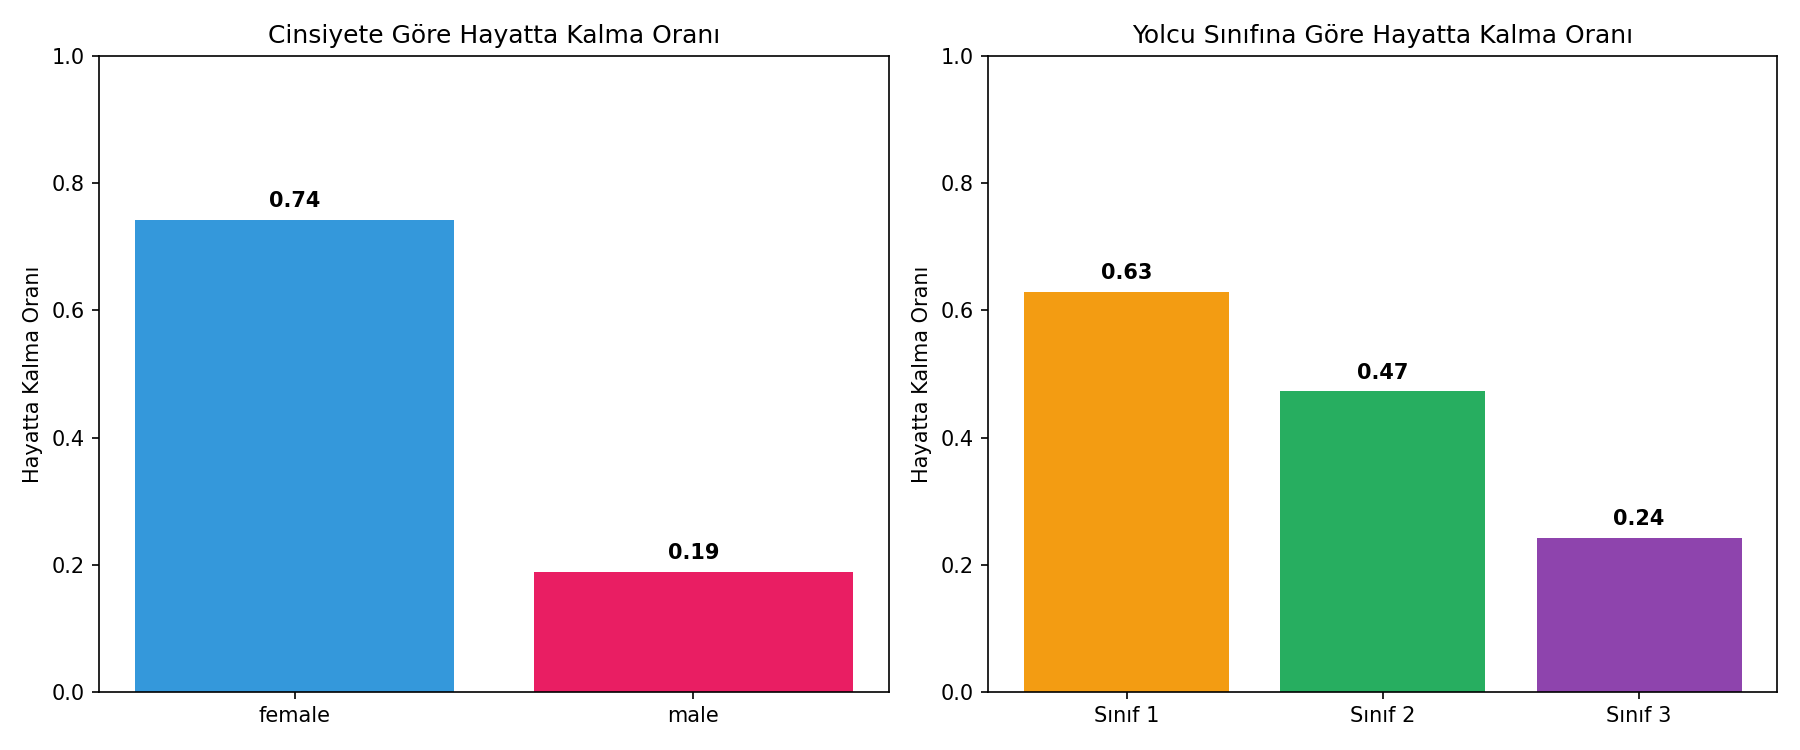

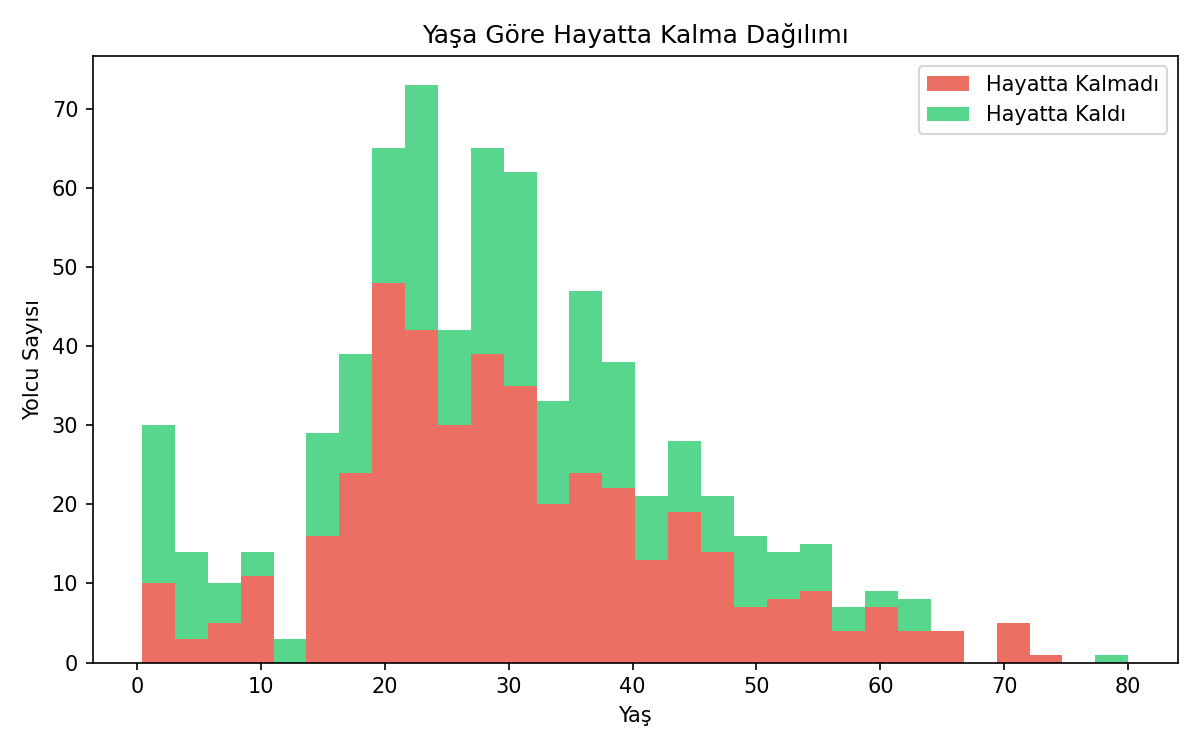

In [3]:
from src.eda import run_eda
from IPython.display import Image, display
from src.config import FIG_DIR

run_eda(df)
for fig in ['fig1_survival_distribution.png', 'fig2_survival_by_sex_class.png', 'fig3_age_distribution.png']:
    display(Image(filename=str(FIG_DIR / fig)))

## Adım 3 — Özellik Mühendisliği

Ham değişkenlerden yeni özellikler türetilir:
- **Title**: `Name` alanından unvan çıkarılır.
- **Deck**: `Cabin` alanının ilk harfi; bilinmiyorsa `'Unknown'`.
- **FamilySize**: `SibSp + Parch + 1`.
- **IsAlone**: FamilySize == 1 ise 1, değilse 0.
- **Port**: `Embarked` kodu → tam şehir adı.

In [4]:
from src.features import engineer_features

df = engineer_features(df)
print('Yeni özellikler:', ['Title', 'Deck', 'FamilySize', 'IsAlone', 'Port'])
df[['Name', 'Title', 'Cabin', 'Deck', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Embarked', 'Port']].head(10)

Yeni özellikler: ['Title', 'Deck', 'FamilySize', 'IsAlone', 'Port']


,Name,Title,Cabin,Deck,SibSp,Parch,FamilySize,IsAlone,Embarked,Port
0,"Braund, Mr. Owen Harris",Mr,NaN,Unknown,1,0,2,0,S,Southampton
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,C85,C,1,0,2,0,C,Cherbourg
2,"Heikkinen, Miss. Laina",Miss,NaN,Unknown,0,0,1,1,S,Southampton
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,C123,C,1,0,2,0,S,Southampton
4,"Allen, Mr. William Henry",Mr,NaN,Unknown,0,0,1,1,S,Southampton
5,"Moran, Mr. James",Mr,NaN,Unknown,0,0,1,1,Q,Queenstown
6,"McCarthy, Mr. Timothy J",Mr,E46,E,0,0,1,1,S,Southampton
7,"Palsson, Master. Gosta Leonard",Master,NaN,Unknown,3,1,5,0,S,Southampton
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,NaN,Unknown,0,2,3,0,S,Southampton
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,NaN,Unknown,1,0,2,0,C,Cherbourg


## Adım 4 — Eksik Değerlerin Giderilmesi

`Age` için (Pclass, Sex) grubuna göre medyan kullanılır.
`Port` için mod ile doldurulur (yalnızca 2 satır eksik).
`Cabin` hiçbir koşulda impute edilmez (%77 eksik).

In [5]:
from src.preprocessing import handle_missing

df = handle_missing(df)
print('Kalan eksik değerler:')
print(df[['Age', 'Port']].isnull().sum())

Kalan eksik değerler:
Age     0
Port    0
dtype: int64


## Adım 5-6 — Yeniden Adlandırma, Gereksiz Sütunları Düşürme ve Kaydetme

Sütunlar okunabilir isimlere dönüştürülür; kimlik/ham metin sütunları kaldırılır.
Kodlama **henüz uygulanmamıştır** — CSV, insan tarafından okunabilir biçimde kaydedilir.

In [6]:
from src.preprocessing import rename_and_drop

df_clean = rename_and_drop(df, save=True)
print('Temiz veri şekli:', df_clean.shape)
df_clean.head()

Temiz veri kaydedildi: /Users/metehansenyer/Desktop/kocaeli-universitesi-yazilim-muhendisligi/25-26 Dönemi/YZM324 - Makine Öğrenmesi Temelleri/Proje/source_code/data/processed/titanic_clean.csv
Temiz veri şekli: (891, 12)


,Survived,PassengerClass,Sex,Age,SiblingsSpouses,ParentsChildren,TicketFare,Title,Deck,FamilySize,IsAlone,Port
0,0,3,male,22.0,1,0,7.2500,Mr,Unknown,2,0,Southampton
1,1,1,female,38.0,1,0,71.2833,Mrs,C,2,0,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Miss,Unknown,1,1,Southampton
3,1,1,female,35.0,1,0,53.1000,Mrs,C,2,0,Southampton
4,0,3,male,35.0,0,0,8.0500,Mr,Unknown,1,1,Southampton


## Adım 7 — Kodlama

`Sex` için label encoding (male=0, female=1) uygulanır.
`Port`, `Title` ve `Deck` için `drop_first=True` ile one-hot encoding yapılır.
Kodlanmış DataFrame yalnızca modelleme için bellekte tutulur.

In [7]:
from src.preprocessing import encode

df_enc = encode(df_clean)
print('Kodlanmış veri şekli:', df_enc.shape)
print('Sütunlar:', list(df_enc.columns))

Kodlanmış veri şekli: (891, 24)
Sütunlar: ['Survived', 'PassengerClass', 'Sex', 'Age', 'SiblingsSpouses', 'ParentsChildren', 'TicketFare', 'FamilySize', 'IsAlone', 'Port_Queenstown', 'Port_Southampton', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


## Adım 8 — Veri Bölme ve Ölçekleme

Stratifiye 80/20 bölme (RANDOM_STATE=42) uygulanır.
`StandardScaler` yalnızca eğitim seti üzerinde fit edilir (veri sızıntısını önler).

In [8]:
from src.modeling import split_data

X_train, X_test, y_train, y_test = split_data(df_enc)
print(f'Eğitim seti: {X_train.shape}')
print(f'Test seti:   {X_test.shape}')
print(f'Eğitim sınıf dağılımı: {y_train.value_counts().to_dict()}')
print(f'Test sınıf dağılımı:   {y_test.value_counts().to_dict()}')

Eğitim seti: (712, 23)
Test seti:   (179, 23)
Eğitim sınıf dağılımı: {0: 439, 1: 273}
Test sınıf dağılımı:   {0: 110, 1: 69}


## Adım 9-10 — Model Eğitimi ve Değerlendirmesi

Dört sınıflandırıcı aynı bölme üzerinde eğitilip değerlendirilir:
- **Logistic Regression** (max_iter=1000)
- **K-Nearest Neighbors** (k=7)
- **Decision Tree** (max_depth=5)
- **Random Forest** (200 ağaç, max_depth=6)

Her model için karışıklık matrisi PNG olarak kaydedilir.

Kaydedilmiş modeller yükleniyor...
Logistic Regression: Accuracy=0.8380, Precision=0.8030, Recall=0.7681, F1=0.7852


K-Nearest Neighbors: Accuracy=0.7877, Precision=0.7385, Recall=0.6957, F1=0.7164
Decision Tree: Accuracy=0.8101, Precision=0.7778, Recall=0.7101, F1=0.7424


Random Forest: Accuracy=0.8212, Precision=0.7937, Recall=0.7246, F1=0.7576
Karışıklık matrisleri:


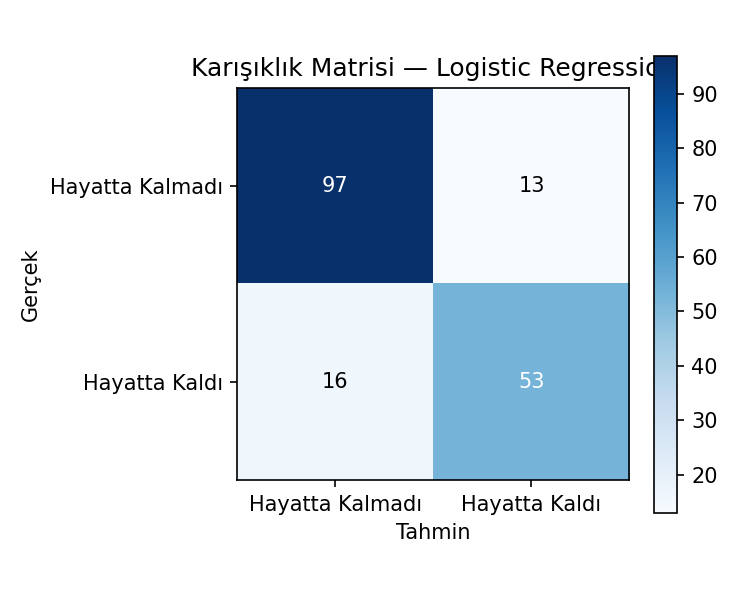

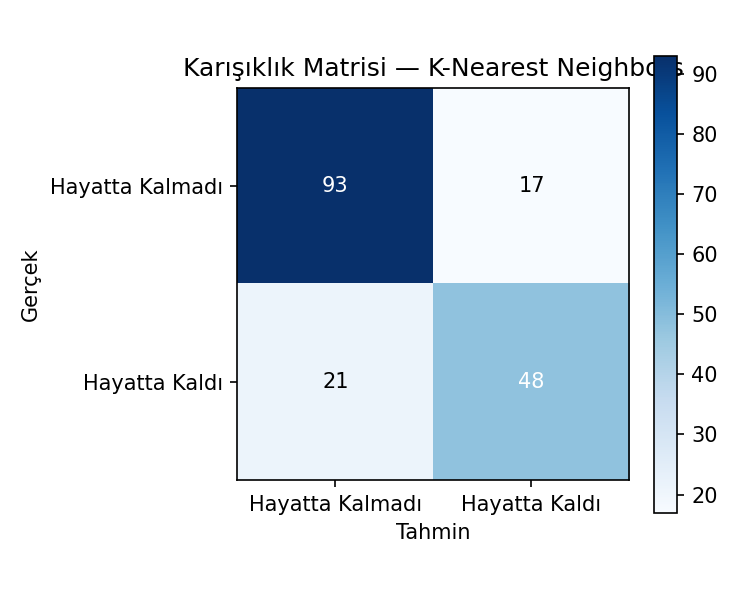

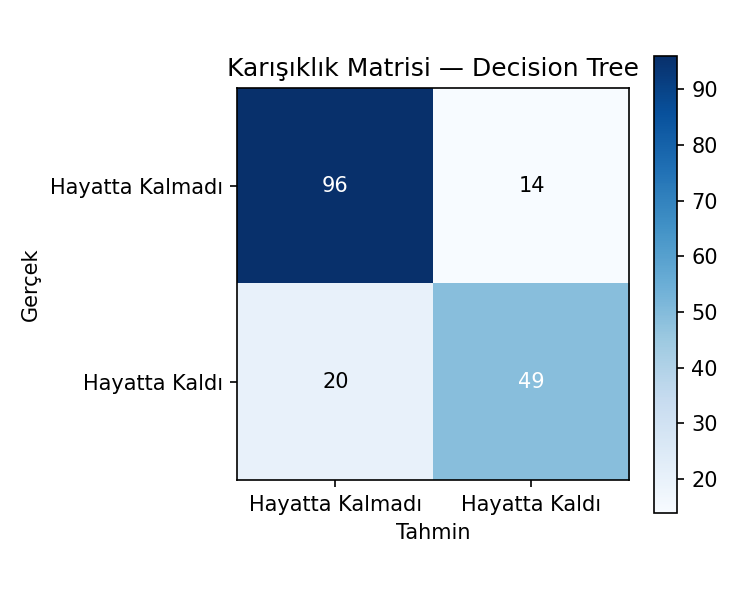

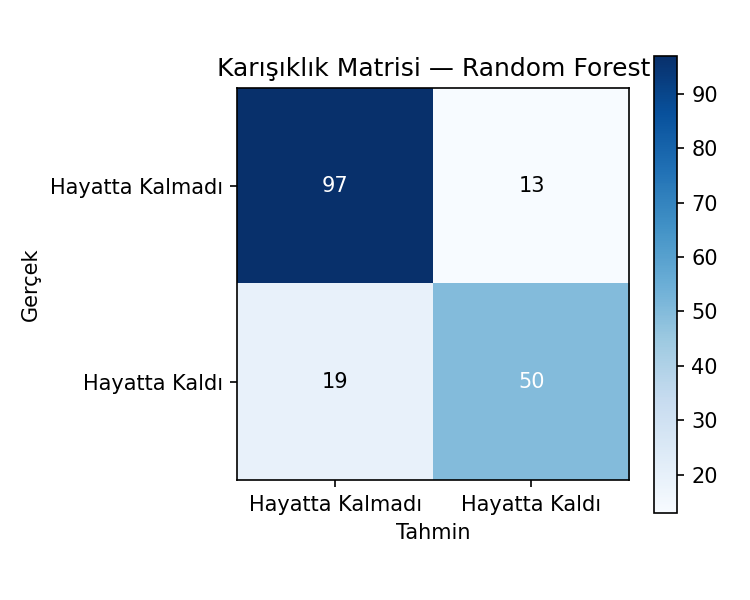

Özellik önemi (Random Forest):


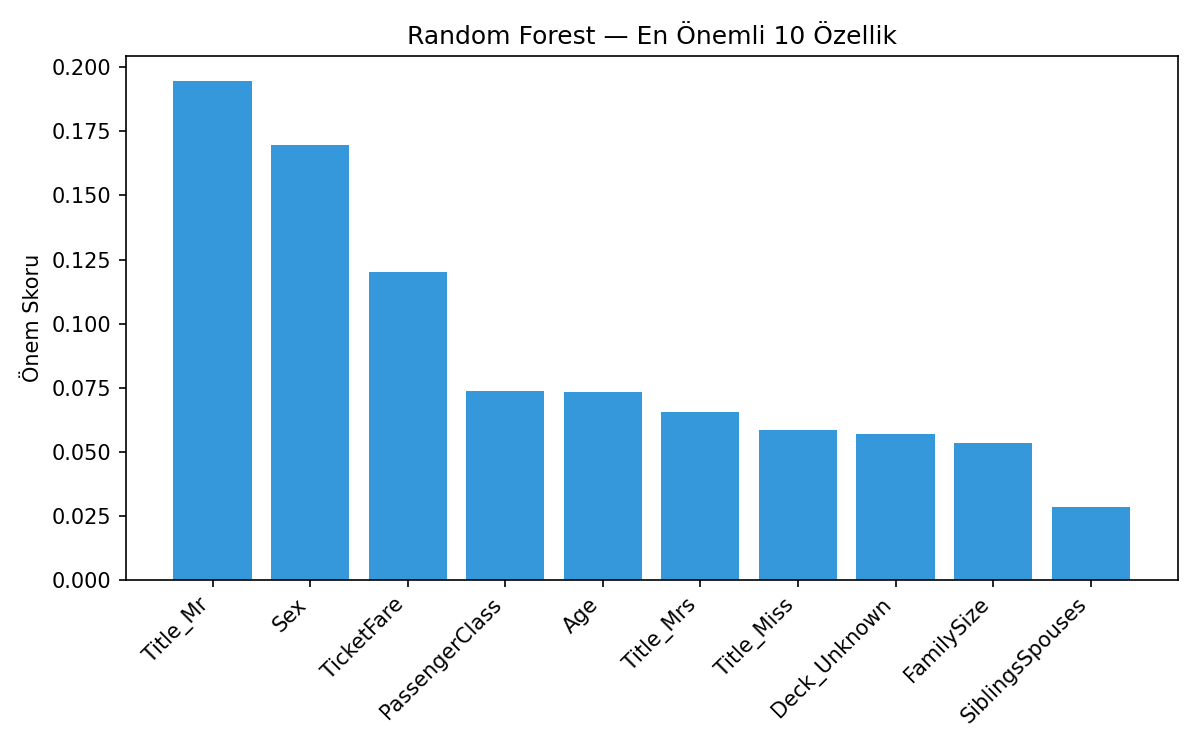

In [9]:
from src.modeling import train_and_evaluate

results_df, fitted_models = train_and_evaluate(X_train, X_test, y_train, y_test)

print('Karışıklık matrisleri:')
for model_name in ['logistic_regression', 'k_nearest_neighbors', 'decision_tree', 'random_forest']:
    display(Image(filename=str(FIG_DIR / f'cm_{model_name}.png')))

print('Özellik önemi (Random Forest):')
display(Image(filename=str(FIG_DIR / 'fig4_feature_importance.png')))

## Adım 11 — Model Karşılaştırması

Tüm modeller accuracy'ye göre sıralanır.
Gruplandırılmış çubuk grafik dört metriği yan yana gösterir.
Nihai tablo `results/model_results.csv` dosyasına kaydedilir.


=== Model Karşılaştırma Sonuçları ===
              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.837989   0.803030 0.768116 0.785185
      Random Forest  0.821229   0.793651 0.724638 0.757576
      Decision Tree  0.810056   0.777778 0.710145 0.742424
K-Nearest Neighbors  0.787709   0.738462 0.695652 0.716418

En iyi model: Logistic Regression (Accuracy: 0.8380)


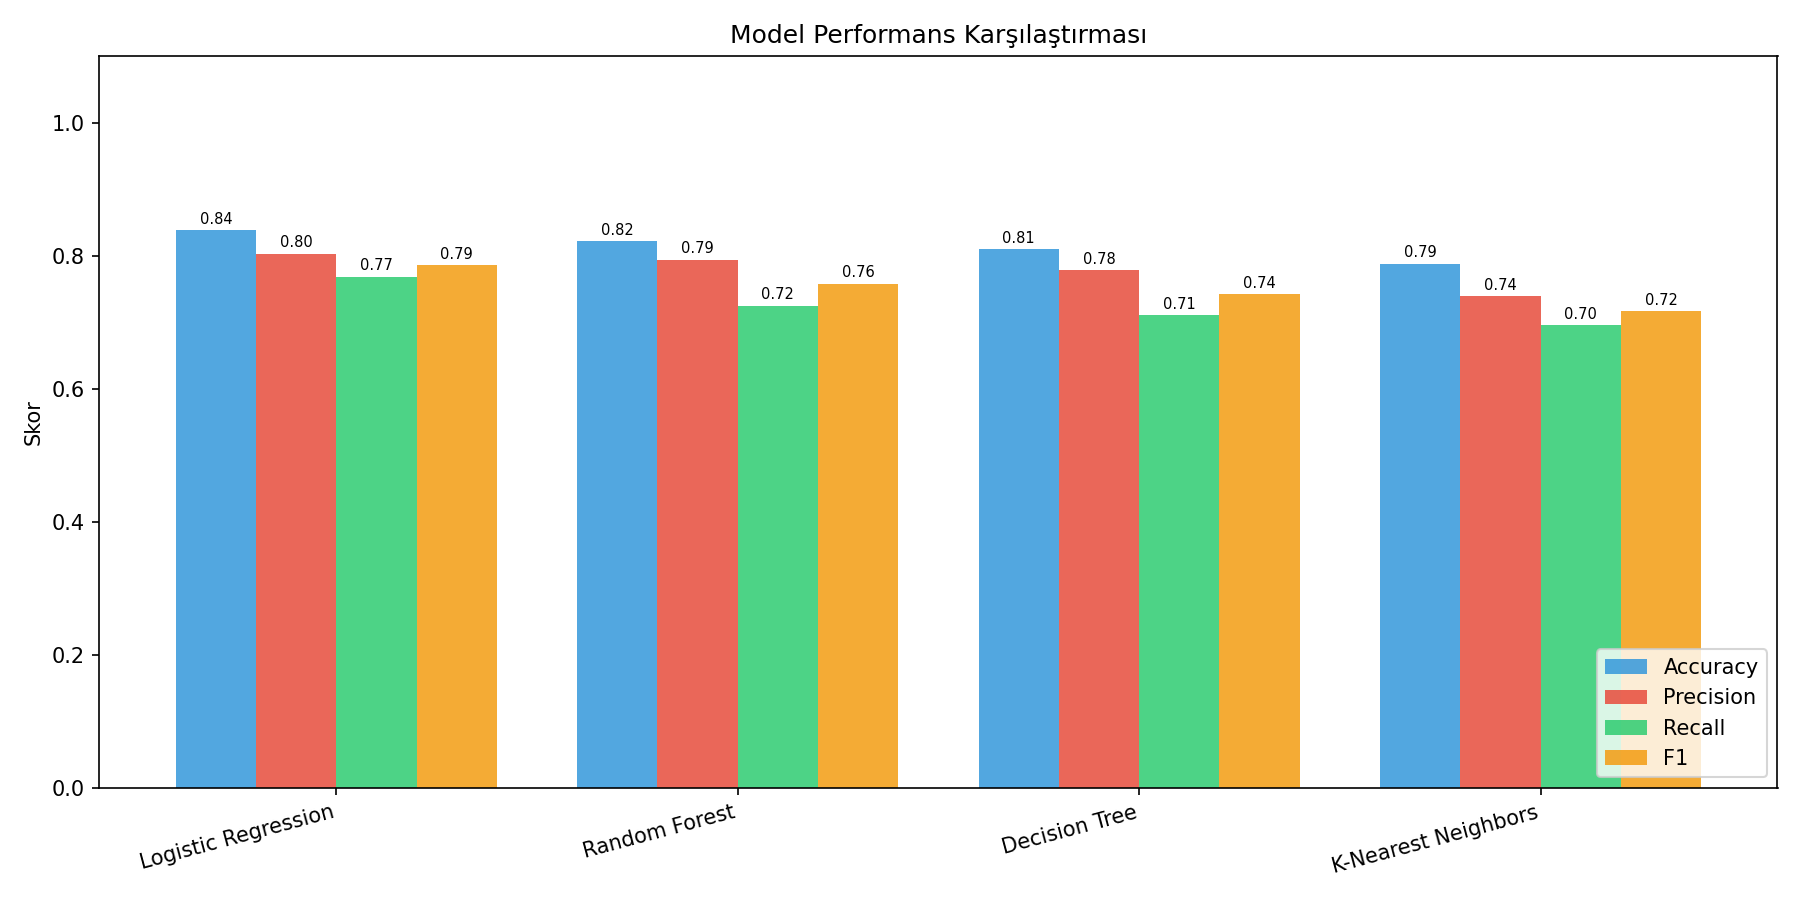

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.837989,0.803030,0.768116,0.785185
1,Random Forest,0.821229,0.793651,0.724638,0.757576
2,Decision Tree,0.810056,0.777778,0.710145,0.742424
3,K-Nearest Neighbors,0.787709,0.738462,0.695652,0.716418


In [10]:
from src.evaluation import compare_models

ranked = compare_models(results_df)
display(Image(filename=str(FIG_DIR / 'fig5_model_comparison.png')))
ranked